# EVE v05 vs EVE API — MCQA Single Answer Debug

Side-by-side comparison of predictions from two runs:
- **eve_v05** — offline model (local LM-eval)
- **eve_api** — EVE API (RAG-augmented)

In [1]:
import pandas as pd
import json
import ast
import textwrap
import ipywidgets as widgets
from IPython.display import display, HTML

pd.set_option('display.max_colwidth', None)

In [2]:
# ── Load data ──────────────────────────────────────────────────────────────
df_v05 = pd.read_csv('eve_v05.csv')
df_api = pd.read_csv('eve_api_mcqa_single.csv')

# Normalise column names: strip any backslash sequences before the dot
# Raw names look like 'doc\\\\.Question' → we want 'doc.Question'
import re
def clean_col(c):
    c = re.sub(r'\\+\.', '.', c)   # doc\\.X  →  doc.X
    c = re.sub(r'^.*"doc_id".*$', 'doc_id', c)  # fix the mangled first column
    return c

df_v05.columns = [clean_col(c) for c in df_v05.columns]
df_api.columns = [clean_col(c) for c in df_api.columns]

print(f'v05 rows: {len(df_v05):,}   |   api rows: {len(df_api):,}')
print('v05 columns :', list(df_v05.columns))
print('api columns :', list(df_api.columns))

v05 rows: 1,261   |   api rows: 1,261
v05 columns : ['doc_id', 'doc.Question', 'target', 'filtered_resps', 'acc', 'arguments', 'doc', 'doc.Answer', 'doc.Choices', 'doc_hash', 'filter', 'metrics', 'prompt_hash', 'resps', 'target_hash']
api columns : ['doc_id', 'doc.Question', 'target', 'filtered_resps', 'acc', 'arguments', 'doc', 'doc.Answer', 'doc.Choices', 'doc_hash', 'eve_api_request', 'eve_api_response', 'filter', 'metrics', 'prompt_hash', 'resps', 'target_hash']


In [3]:
# ── Helpers ────────────────────────────────────────────────────────────────
def safe_parse(val):
    """Parse a list-like string, return first element."""
    if pd.isna(val):
        return ''
    try:
        parsed = ast.literal_eval(str(val))
        if isinstance(parsed, list) and parsed:
            return parsed[0]
        return str(parsed)
    except (ValueError, SyntaxError):
        return str(val)

def parse_doc(doc_str):
    try:
        return json.loads(str(doc_str))
    except (json.JSONDecodeError, ValueError):
        return {}

def parse_response(resp_str):
    try:
        return json.loads(str(resp_str))
    except (json.JSONDecodeError, ValueError):
        return {}

# ── Build merged dataframe ─────────────────────────────────────────────────
merged = df_v05[['doc_id', 'doc.Question', 'doc.Choices', 'doc.Answer',
                 'target', 'filtered_resps', 'acc', 'doc']].copy()
merged = merged.rename(columns={'filtered_resps': 'v05_pred', 'acc': 'v05_acc'})
merged['v05_pred'] = merged['v05_pred'].apply(safe_parse)

api_cols = df_api[['doc_id', 'filtered_resps', 'acc',
                   'eve_api_request', 'eve_api_response']].copy()
api_cols = api_cols.rename(columns={'filtered_resps': 'api_pred', 'acc': 'api_acc'})
api_cols['api_pred'] = api_cols['api_pred'].apply(safe_parse)

merged = merged.merge(api_cols, on='doc_id', how='inner').reset_index(drop=True)
print(f'Merged rows: {len(merged):,}')

# ── Outcome category ───────────────────────────────────────────────────────
def outcome(row):
    v, a = int(row['v05_acc']), int(row['api_acc'])
    if v == 1 and a == 1: return 'Both correct'
    if v == 0 and a == 0: return 'Both wrong'
    if v == 0 and a == 1: return 'API wins'
    return 'v05 wins'

merged['outcome'] = merged.apply(outcome, axis=1)
print(merged['outcome'].value_counts().to_string())

Merged rows: 1,261
outcome
Both correct    1175
v05 wins          40
Both wrong        34
API wins          12


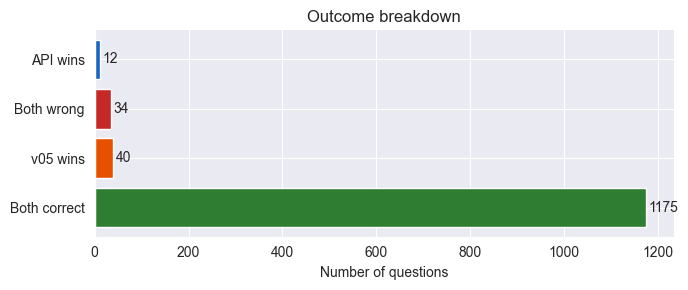

In [4]:
# ── Accuracy summary ───────────────────────────────────────────────────────
v05_acc  = merged['v05_acc'].mean()
api_acc  = merged['api_acc'].mean()

display(HTML(f"""
<div style="display:flex;gap:24px;font-family:monospace;margin-bottom:8px">
  <div style="background:#e8f4f8;border-radius:8px;padding:16px 28px;text-align:center">
    <div style="font-size:13px;color:#555">eve_v05 accuracy</div>
    <div style="font-size:28px;font-weight:bold;color:#1a6fa3">{v05_acc:.1%}</div>
  </div>
  <div style="background:#edf8ee;border-radius:8px;padding:16px 28px;text-align:center">
    <div style="font-size:13px;color:#555">eve_api accuracy</div>
    <div style="font-size:28px;font-weight:bold;color:#2e7d32">{api_acc:.1%}</div>
  </div>
  <div style="background:#fdf3e7;border-radius:8px;padding:16px 28px;text-align:center">
    <div style="font-size:13px;color:#555">delta (api − v05)</div>
    <div style="font-size:28px;font-weight:bold;color:{'#2e7d32' if api_acc >= v05_acc else '#c62828'}">{api_acc - v05_acc:+.1%}</div>
  </div>
  <div style="background:#f3f0fb;border-radius:8px;padding:16px 28px;text-align:center">
    <div style="font-size:13px;color:#555">total questions</div>
    <div style="font-size:28px;font-weight:bold;color:#4a148c">{len(merged):,}</div>
  </div>
</div>
"""))

# Outcome breakdown bar chart
outcome_counts = merged['outcome'].value_counts()
try:
    import matplotlib.pyplot as plt
    colors = {'Both correct':'#2e7d32','Both wrong':'#c62828','API wins':'#1565c0','v05 wins':'#e65100'}
    fig, ax = plt.subplots(figsize=(7, 3))
    bars = ax.barh(outcome_counts.index, outcome_counts.values,
                   color=[colors.get(o, '#888') for o in outcome_counts.index])
    for bar, n in zip(bars, outcome_counts.values):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                str(n), va='center', fontsize=10)
    ax.set_xlabel('Number of questions')
    ax.set_title('Outcome breakdown')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()
except ImportError:
    print(outcome_counts)

In [5]:
from ipywidgets import widgets as W
from IPython.display import clear_output
import traceback

CHOICE_LETTERS = 'ABCDEFGHIJ'

BG      = {'Both correct':'#1a3a2a','Both wrong':'#3a1a1a','API wins':'#1a2a3a','v05 wins':'#3a2a1a'}
TEXT    = '#e8e8e8'
SUBTEXT = '#aaaaaa'
DOC_BG  = '#1e1e1e'
PRE_BG  = '#141414'

def fmt_score(val):
    return f'{float(val):.3f}' if val is not None else 'n/a'

def render(row, idx, total):
    question = row['doc.Question']
    choices  = row['doc.Choices']
    if isinstance(choices, str):
        try:    choices = json.loads(choices)
        except: choices = ast.literal_eval(choices)

    choices_html = ''.join(
        f'<div style="margin:3px 0;color:{TEXT}"><b style="color:#ccc">{CHOICE_LETTERS[i]}.</b> {c}</div>'
        for i, c in enumerate(choices)
    )

    def badge(ok, pred):
        color = '#4caf80' if ok else '#e57373'
        return f'<span style="background:{color};color:#111;border-radius:4px;padding:2px 9px;font-weight:bold">{"✓" if ok else "✗"} {pred}</span>'

    bg   = BG.get(row['outcome'], '#2a2a2a')
    docs = parse_response(row['eve_api_response']).get('documents', [])

    doc_cards = ''
    for i, d in enumerate(docs):
        p       = d.get('payload', {})
        title   = p.get('title') or d.get('metadata', {}).get('title') or '—'
        raw     = p.get('content') or d.get('text', '')
        text    = raw.replace('<','&lt;').replace('>','&gt;')
        journal = p.get('journal', '')
        year    = p.get('year', '')
        doi     = p.get('doi', '')
        score   = fmt_score(d.get('score'))
        rerank  = d.get('reranking_score')
        rerank_str = f' | rerank:{fmt_score(rerank)}' if rerank is not None else ''
        doi_html = f'<a href="https://doi.org/{doi}" target="_blank" style="color:#7ab4e8">{doi}</a>' if doi else '—'
        doc_cards += f"""
        <details style="margin:4px 0;border:1px solid #444;border-radius:6px;background:{DOC_BG}">
          <summary style="padding:5px 10px;cursor:pointer;font-size:13px;color:{TEXT}">
            <span style="color:#9ecdf5;font-weight:500">[{i+1}]</span> {title}
            <span style="float:right;color:{SUBTEXT};font-size:12px;font-weight:normal">
              score:{score}{rerank_str} | {d.get('collection_name','')}
            </span>
          </summary>
          <div style="padding:8px 12px;font-size:12px;color:{TEXT}">
            <div><b style="color:#ccc">Journal:</b> {journal} ({year}) &nbsp;<b style="color:#ccc">DOI:</b> {doi_html}</div>
            <pre style="margin:6px 0;background:{PRE_BG};border-left:3px solid #555;padding:6px;font-size:11px;overflow-y:auto;white-space:pre-wrap;color:#c8c8c8">{text}</pre>
          </div>
        </details>"""

    return f"""
    <div style="background:{bg};border-radius:10px;padding:18px 22px;font-family:system-ui,sans-serif;font-size:14px;line-height:1.6;color:{TEXT}">
      <div style="display:flex;justify-content:space-between;color:{SUBTEXT};font-size:12px;margin-bottom:8px">
        <span>doc_id: {row['doc_id']}</span>
        <span style="font-weight:bold;color:#ddd">{row['outcome']} &nbsp;({idx+1}/{total})</span>
      </div>
      <div style="font-size:15px;font-weight:600;margin-bottom:10px;color:#f0f0f0">{question}</div>
      <div style="background:rgba(255,255,255,0.07);border-radius:6px;padding:8px 14px;margin-bottom:12px">{choices_html}</div>
      <div style="display:flex;gap:16px;align-items:center;margin-bottom:12px">
        <span><b style="color:#ccc">Correct:</b> <b style="font-size:16px;color:#f0f0f0">{row['target']}</b></span>
        <span><b style="color:#ccc">eve_v05:</b> {badge(bool(int(row['v05_acc'])), str(row['v05_pred']))}</span>
        <span><b style="color:#ccc">eve_api:</b> {badge(bool(int(row['api_acc'])), str(row['api_pred']))}</span>
      </div>
      <div style="font-weight:600;font-size:13px;margin-bottom:4px;color:#ccc">Retrieved documents ({len(docs)})</div>
      {doc_cards or f'<i style="color:{SUBTEXT}">No documents</i>'}
    </div>"""


# ── State & widgets ────────────────────────────────────────────────────────
OUTCOME_OPTIONS = ['All'] + sorted(merged['outcome'].unique().tolist())
state = {'subset': merged.copy()}

out = W.Output()

filter_buttons = W.ToggleButtons(
    options=OUTCOME_OPTIONS, value='All', description='',
    style={'button_width': 'auto'},
)
slider = W.IntSlider(
    min=0, max=len(merged)-1, step=1, value=0,
    description='Question #', continuous_update=False,
    style={'description_width': 'initial'},
    layout=W.Layout(width='700px'),
)

def refresh(idx):
    subset = state['subset']
    idx    = min(max(idx, 0), len(subset) - 1)
    row    = subset.iloc[idx]
    with out:
        clear_output(wait=True)
        try:
            display(HTML(render(row, idx, len(subset))))
        except Exception:
            print(traceback.format_exc())

def on_filter(change):
    if change['name'] != 'value':
        return
    sel    = filter_buttons.value
    subset = merged if sel == 'All' else merged[merged['outcome'] == sel]
    state['subset'] = subset.reset_index(drop=True)
    slider.unobserve(on_slide, names='value')
    slider.max   = max(len(state['subset']) - 1, 0)
    slider.value = 0
    slider.observe(on_slide, names='value')
    refresh(0)

def on_slide(change):
    if change['name'] != 'value':
        return
    refresh(slider.value)

filter_buttons.observe(on_filter, names='value')
slider.observe(on_slide, names='value')

refresh(0)
display(filter_buttons, slider, out)

ToggleButtons(options=('All', 'API wins', 'Both correct', 'Both wrong', 'v05 wins'), style=ToggleButtonsStyle(…

IntSlider(value=0, continuous_update=False, description='Question #', layout=Layout(width='700px'), max=1260, …

Output()